# Testing

In [10]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from dataset import SICAPMultiSlideDataset, get_slide_ids


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [4]:
FEATURES_DIR = "/home/nadun/wd/datasets/SICAP-test/features"
MASKS_DIR = "/home/nadun/wd/datasets/SICAP-test/masks"

## Create dataset

In [5]:
# Get all available slide IDs
slide_ids = get_slide_ids(FEATURES_DIR)
print(f"Total slides: {len(slide_ids)}")

dataset = SICAPMultiSlideDataset(
        slide_ids=slide_ids,
        features_dir=FEATURES_DIR,
        masks_dir=MASKS_DIR
    )
print(f"Total dataset size: {len(dataset)} patches")

Total slides: 155
Total dataset size: 18783 patches


### Visualize dataset

/home/nadun/wd/datasets/SICAP-test/masks/16B0006695/16B0006695_Block_Region_3_5_6_xini_12115_yini_111874.jpg
/home/nadun/wd/datasets/SICAP-test/masks/16B0026792/16B0026792_Block_Region_3_0_1_xini_9702_yini_91096.jpg
/home/nadun/wd/datasets/SICAP-test/masks/18B0005478F/18B0005478F_Block_Region_8_30_21_xini_27271_yini_128914.jpg
/home/nadun/wd/datasets/SICAP-test/masks/17B0031890/17B0031890_Block_Region_1_16_8_xini_15447_yini_70507.jpg
/home/nadun/wd/datasets/SICAP-test/masks/16B0026794/16B0026794_Block_Region_11_36_26_xini_39593_yini_172373.jpg


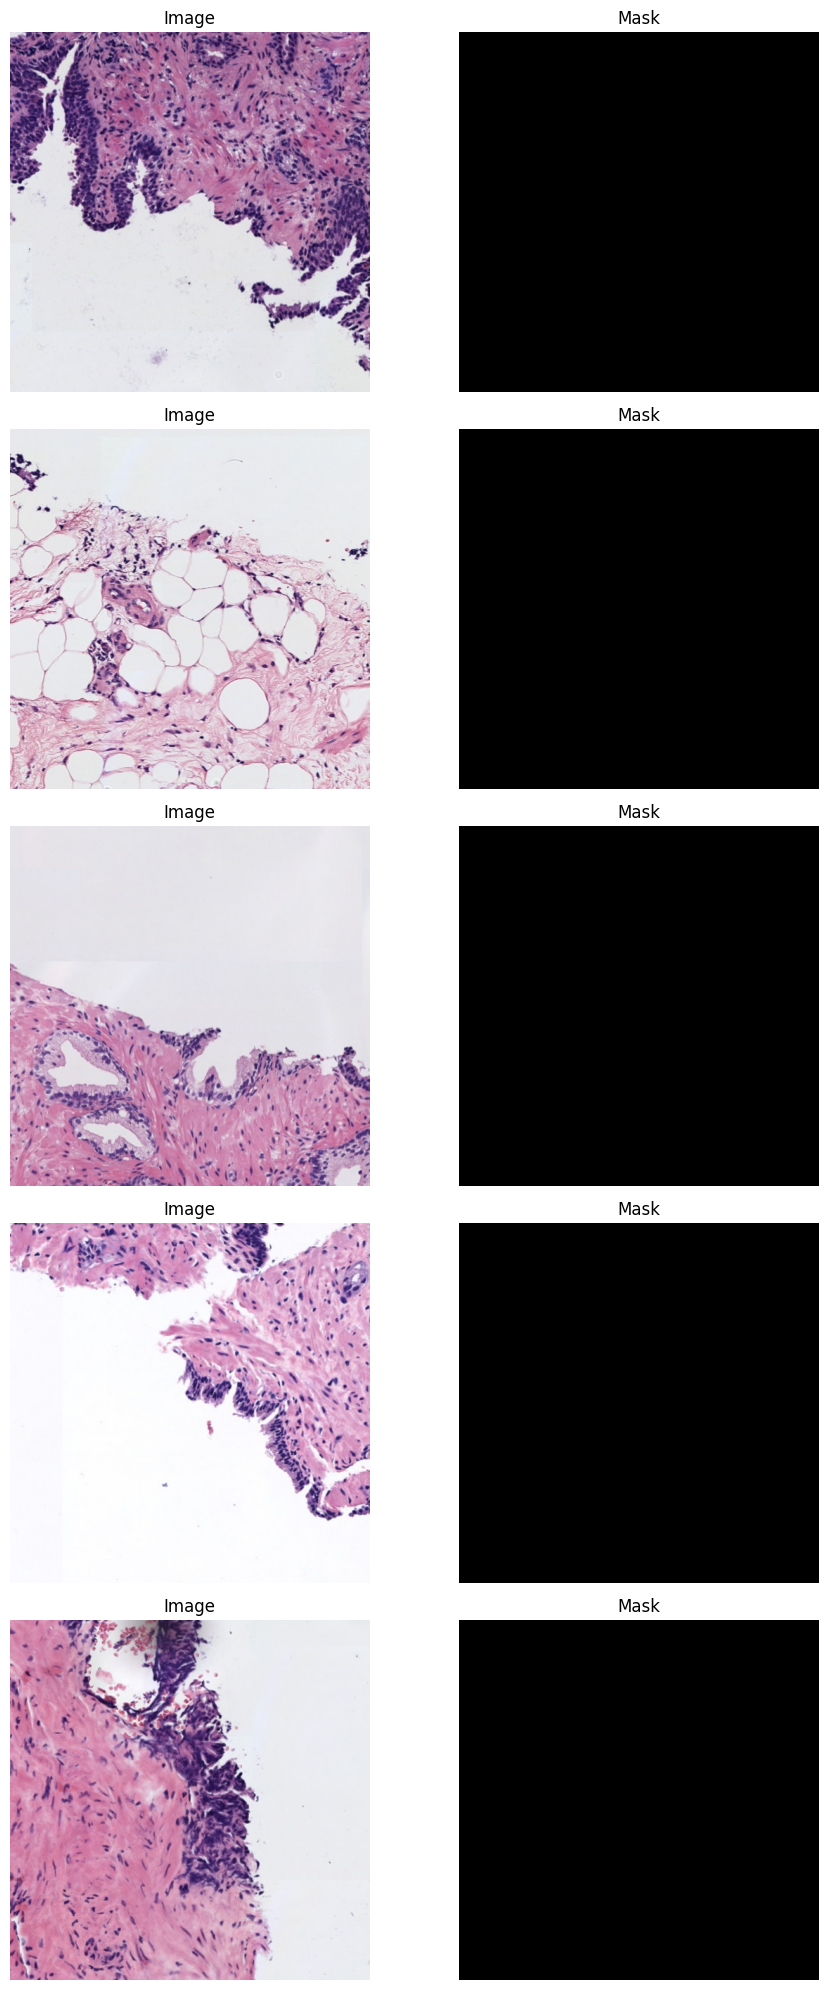

In [24]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap([
    "black",   # class 0
    "red",     # class 1
    "green",   # class 2
    "blue"     # class 3
])

# Plot random samples and their masks
num_samples = 5
fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))

for i in range(num_samples):
    idx = np.random.randint(0, len(dataset))
    
    patch = dataset[idx]["filename"]
    slide_id = dataset[idx]["slide_id"]
    path = f"/home/nadun/wd/datasets/SICAP-test/images/{slide_id}/{patch}.jpg"
    mask_path = f"/home/nadun/wd/datasets/SICAP-test/masks/{slide_id}/{patch}.jpg"
    print(mask_path)

    # Load image
    image = Image.open(path).convert("RGB")
    image = np.array(image)

    # Load mask
    mask = dataset[idx]["mask"].squeeze().cpu().numpy()  # [512, 512]

    # Plot image
    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    # Plot mask (FIXED)
    axes[i, 1].imshow(
        mask,
        cmap=cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest"
    )
    axes[i, 1].set_title("Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## 